In [9]:
!pip install tensorflow matplotlib tensorflow_io

In [10]:
import os
from matplotlib import pyplot as plt
import tensorflow as tf 
import tensorflow_io as tfio


In [11]:
WHISTLE_FILE = os.path.join('/Users','raihera','project','whistles', 'yes', 'pressure-cooker-543110yes.wav')
NOT_WHISTLE_FILE = os.path.join('/Users','raihera','project','whistles', 'no', 'afternoon-birds-song-in-forest-0.wav')

In [12]:
WHISTLE_FILE

'/Users/raihera/project/whistles/yes/pressure-cooker-543110yes.wav'

In [13]:
def load_wav_16k_mono(filename):
    # Load encoded wav file
    file_contents = tf.io.read_file(filename)
    # Decode wav (tensors by channels) 
    wav, sample_rate = tf.audio.decode_wav(file_contents, desired_channels=1)
    # Removes trailing axis
    wav = tf.squeeze(wav, axis=-1)
    sample_rate = tf.cast(sample_rate, dtype=tf.int64)
    # Goes from 44100Hz to 16000hz - amplitude of the audio signal
    wav = tfio.audio.resample(wav, rate_in=sample_rate, rate_out=16000)
    return wav

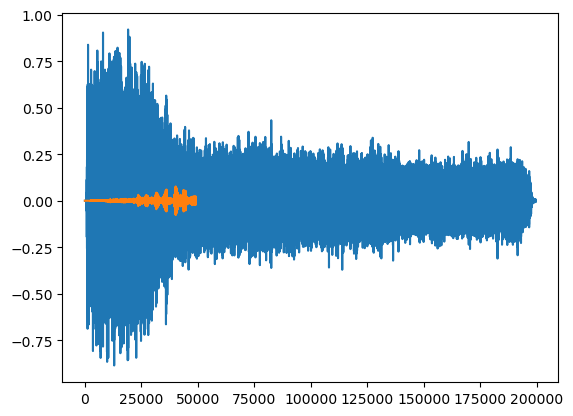

In [14]:
wave = load_wav_16k_mono(WHISTLE_FILE)
nowave = load_wav_16k_mono(NOT_WHISTLE_FILE)
plt.plot(wave)
plt.plot(nowave)
plt.show()

In [15]:
POS = os.path.join('/Users','raihera','project','whistles', 'yes')
NEG = os.path.join('/Users','raihera','project','whistles', 'no')

In [16]:
NEG

'/Users/raihera/project/whistles/no'

In [17]:
pos = tf.data.Dataset.list_files(POS+'/*.wav')
neg = tf.data.Dataset.list_files(NEG+'/*.wav')

In [18]:
pos.as_numpy_iterator().next()

b'/Users/raihera/project/whistles/yes/pressure-cooker-whistle-271190yes.wav'

In [19]:
len(pos)

9

In [20]:
positives = tf.data.Dataset.zip((pos, tf.data.Dataset.from_tensor_slices(tf.ones(len(pos)))))
negatives = tf.data.Dataset.zip((neg, tf.data.Dataset.from_tensor_slices(tf.zeros(len(neg)))))
data = positives.concatenate(negatives)

In [21]:
positives.as_numpy_iterator().next()

(b'/Users/raihera/project/whistles/yes/pressure-cooker-543112yes.wav', 1.0)

In [22]:
negatives.as_numpy_iterator().next()

(b'/Users/raihera/project/whistles/no/pressure-cooker-5431122no.wav', 0.0)

In [23]:
data.as_numpy_iterator().next()

(b'/Users/raihera/project/whistles/yes/pressure-cooker-543112yes.wav', 1.0)

Parse all files for length of bird sound

In [24]:
lengths = []
for file in os.listdir('/Users/raihera/project/whistles/yes'):
    if file.endswith('.wav'):
        tensor_wave = load_wav_16k_mono(os.path.join('/Users','raihera','project','whistles', 'yes', file))
        lengths.append(len(tensor_wave))

In [25]:
tf.math.reduce_mean(lengths)

<tf.Tensor: shape=(), dtype=int32, numpy=68342>

In [26]:
149905/44100

3.399206349206349

4.2 Calculate Mean, Min and Max


In [27]:
tf.math.reduce_mean(lengths)


<tf.Tensor: shape=(), dtype=int32, numpy=68342>

In [28]:
tf.math.reduce_min(lengths)


<tf.Tensor: shape=(), dtype=int32, numpy=15216>

In [29]:
tf.math.reduce_max(lengths)


<tf.Tensor: shape=(), dtype=int32, numpy=199476>

Pre processing

In [30]:
def preprocess(file_path, label): 
    print("test",file_path)
    wav = load_wav_16k_mono(file_path)
    wav = wav[:48000]
    zero_padding = tf.zeros([48000] - tf.shape(wav), dtype=tf.float32)
    wav = tf.concat([zero_padding, wav],0)
    spectrogram = tf.signal.stft(wav, frame_length=320, frame_step=32)
    spectrogram = tf.abs(spectrogram)
    spectrogram = tf.expand_dims(spectrogram, axis=2)
    return spectrogram, label

In [31]:
filepath, label = positives.shuffle(buffer_size=10000).as_numpy_iterator().next()


In [32]:
filepath

b'/Users/raihera/project/whistles/yes/pressure-cooker-5431124yes.wav'

In [33]:
spectrogram, label = preprocess(filepath, label)


test b'/Users/raihera/project/whistles/yes/pressure-cooker-5431124yes.wav'


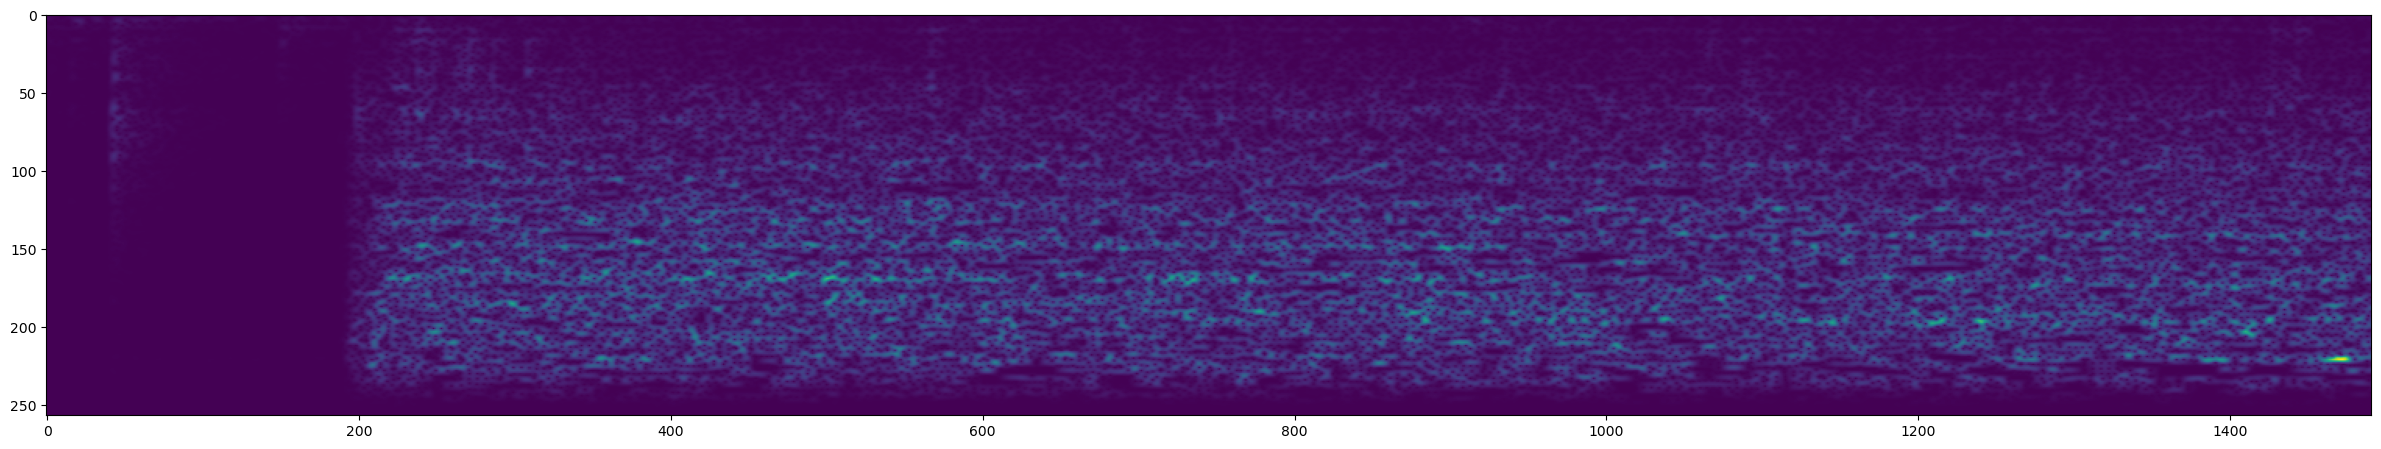

In [34]:
plt.figure(figsize=(30,20))
plt.imshow(tf.transpose(spectrogram)[0])
plt.show()

Data pipeline

In [35]:
data = data.map(preprocess)
data = data.cache()
data = data.shuffle(buffer_size=1000)
data = data.batch(16)
data = data.prefetch(8)

test Tensor("args_0:0", shape=(), dtype=string)


70% partition

In [36]:
len(data)

3

In [37]:
train = data.take(2)
test = data.skip(2).take(1)

Test

In [38]:
samples, labels = train.as_numpy_iterator().next()


In [39]:
samples.shape

(16, 1491, 257, 1)

7.2 Build Sequential Model, Compile and View Summary


In [40]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Dense, Flatten

In [41]:
model = Sequential()
model.add(Conv2D(16, (3,3), activation='relu', input_shape=(1491, 257,1)))
model.add(Conv2D(16, (3,3), activation='relu'))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

In [42]:
model.compile('Adam', loss='BinaryCrossentropy', metrics=[tf.keras.metrics.Recall(),tf.keras.metrics.Precision()])


In [43]:
model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 1489, 255, 16)     160       
                                                                 
 conv2d_1 (Conv2D)           (None, 1487, 253, 16)     2320      
                                                                 
 flatten (Flatten)           (None, 6019376)           0         
                                                                 
 dense (Dense)               (None, 128)               770480256 
                                                                 
 dense_1 (Dense)             (None, 1)                 129       
                                                                 
Total params: 770482865 (2.87 GB)
Trainable params: 770482865 (2.87 GB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [44]:
hist = model.fit(train, epochs=4, validation_data=test)

Epoch 1/4
2/2 [==============================] - 133s 67s/step - loss: 12.6313 - recall: 0.7143 - precision: 0.2083 - val_loss: 0.7140 - val_recall: 1.0000 - val_precision: 0.6667
Epoch 2/4
2/2 [==============================] - 139s 73s/step - loss: 23.0964 - recall: 0.8750 - precision: 0.7778 - val_loss: 31.0533 - val_recall: 1.0000 - val_precision: 0.6667
Epoch 3/4
2/2 [==============================] - 171s 90s/step - loss: 42.7560 - recall: 0.5714 - precision: 0.8000 - val_loss: 3.8230e-17 - val_recall: 1.0000 - val_precision: 1.0000
Epoch 4/4
2/2 [==============================] - 209s 113s/step - loss: 11.7331 - recall: 0.7500 - precision: 0.8571 - val_loss: 5.7714e-05 - val_recall: 1.0000 - val_precision: 1.0000


In [45]:
hist.history

{'loss': [12.6312837600708,
  23.096376419067383,
  42.755958557128906,
  11.733119010925293],
 'recall': [0.7142857313156128, 0.875, 0.5714285969734192, 0.75],
 'precision': [0.2083333283662796,
  0.7777777910232544,
  0.800000011920929,
  0.8571428656578064],
 'val_loss': [0.7139838933944702,
  31.05333709716797,
  3.8230322531065513e-17,
  5.771444193669595e-05],
 'val_recall': [1.0, 1.0, 1.0, 1.0],
 'val_precision': [0.6666666865348816, 0.6666666865348816, 1.0, 1.0]}

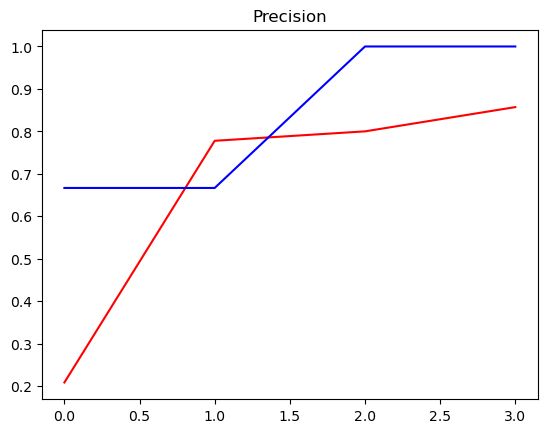

In [46]:
plt.title('Precision')
plt.plot(hist.history['precision'], 'r')
plt.plot(hist.history['val_precision'], 'b')
plt.show()

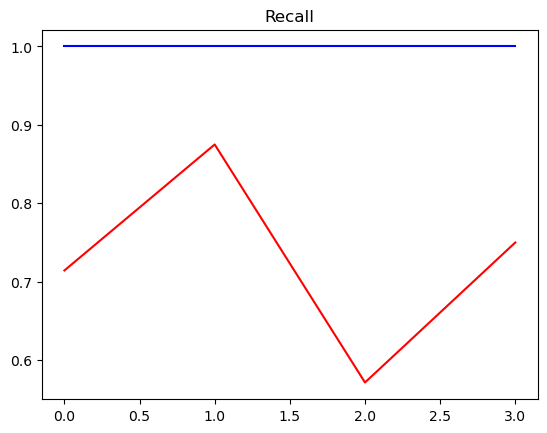

In [47]:
plt.title('Recall')
plt.plot(hist.history['recall'], 'r')
plt.plot(hist.history['val_recall'], 'b')
plt.show()

In [48]:
X_test, y_test = test.as_numpy_iterator().next()


In [49]:
yhat = model.predict(X_test)


1/1 [==============================] - 1s 1s/step


In [50]:
yhat = [1 if prediction > 0.5 else 0 for prediction in yhat]

In [51]:
yhat

[0, 0, 0, 1, 0, 0, 0, 1]

In [52]:
yhat

[0, 0, 0, 1, 0, 0, 0, 1]

In [53]:
y_test

array([0., 0., 0., 1., 0., 0., 0., 1.], dtype=float32)

Load Mp3


In [54]:
def load_mp3_16k_mono(filename):
    """ Load a WAV file, convert it to a float tensor, resample to 16 kHz single-channel audio. """
    res = tfio.audio.AudioIOTensor(filename)
    # Convert to tensor and combine channels 
    tensor = res.to_tensor()
    tensor = tf.math.reduce_sum(tensor, axis=1) / 2 
    # Extract sample rate and cast
    sample_rate = res.rate
    sample_rate = tf.cast(sample_rate, dtype=tf.int64)
    # Resample to 16 kHz
    wav = tfio.audio.resample(tensor, rate_in=sample_rate, rate_out=16000)
    return wav

In [55]:
mp3 = os.path.join('/Users','raihera','project','whistles', 'whistles_sound', 'air-or-steam-pressure-release-29600.wav')

In [56]:
wav = load_mp3_16k_mono(mp3)

In [57]:
audio_slices = tf.keras.utils.timeseries_dataset_from_array(wav, wav, sequence_length=48000, sequence_stride=48000, batch_size=1)

In [58]:
samples, index = audio_slices.as_numpy_iterator().next()

In [59]:
samples.shape

(1, 48000)

In [60]:
def preprocess_mp3(sample, index):
    sample = sample[0]
    zero_padding = tf.zeros([48000] - tf.shape(sample), dtype=tf.float32)
    wav = tf.concat([zero_padding, sample],0)
    spectrogram = tf.signal.stft(wav, frame_length=320, frame_step=32)
    spectrogram = tf.abs(spectrogram)
    spectrogram = tf.expand_dims(spectrogram, axis=2)
    return spectrogram

In [61]:
audio_slices = tf.keras.utils.timeseries_dataset_from_array(wav, wav, sequence_length=48000, sequence_stride=48000, batch_size=1)
audio_slices = audio_slices.map(preprocess_mp3)
audio_slices = audio_slices.batch(64)

In [62]:
yhat = model.predict(audio_slices)
yhat = [1 if prediction > 0.99 else 0 for prediction in yhat]

1/1 [==============================] - 0s 481ms/step


In [63]:
len(yhat)

5

In [64]:
yhat

[1, 1, 0, 1, 1]

In [65]:
from itertools import groupby


In [66]:
yhat = [key for key, group in groupby(yhat)]
calls = tf.math.reduce_sum(yhat).numpy()

In [67]:
calls

2

In [68]:
results = {}
for file in os.listdir(os.path.join('/Users','raihera','project','whistles', 'full_tracks')):
    FILEPATH = os.path.join('/Users','raihera','project','whistles', 'full_tracks', file)
    
    wav = load_mp3_16k_mono(FILEPATH)
    audio_slices = tf.keras.utils.timeseries_dataset_from_array(wav, wav, sequence_length=48000, sequence_stride=48000, batch_size=1)
    audio_slices = audio_slices.map(preprocess_mp3)
    audio_slices = audio_slices.batch(64)
    
    yhat = model.predict(audio_slices)
    
    results[file] = yhat

1/1 [==============================] - 1s 653ms/step


In [70]:
results

{'air-or-steam-pressure-release-29600.wav': array([[1.],
        [1.],
        [0.],
        [1.],
        [1.]], dtype=float32),
 'pressure-cooker-54311.wav': array([[1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [0.],
        [1.],
        [1.],
        [1.],
        [0.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.]], dtype=float32),
 'pressure-cooker-whistle-27119.wav': array([[1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [0.],
        [1.],
        [1.],
        [1.],
        [1.]], dtype=float32)}

In [71]:
class_preds = {}
for file, logits in results.items():
    class_preds[file] = [1 if prediction > 0.99 else 0 for prediction in logits]
class_preds

{'air-or-steam-pressure-release-29600.wav': [1, 1, 0, 1, 1],
 'pressure-cooker-54311.wav': [1,
  1,
  1,
  1,
  1,
  0,
  1,
  1,
  1,
  0,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1],
 'pressure-cooker-whistle-27119.wav': [1, 1, 1, 1, 1, 0, 1, 1, 1, 1]}

In [72]:
postprocessed = {}
for file, scores in class_preds.items():
    postprocessed[file] = tf.math.reduce_sum([key for key, group in groupby(scores)]).numpy()
postprocessed

{'air-or-steam-pressure-release-29600.wav': 2,
 'pressure-cooker-54311.wav': 3,
 'pressure-cooker-whistle-27119.wav': 2}

In [73]:
postprocessed = dict(sorted(postprocessed.items()))


In [74]:
postprocessed

{'air-or-steam-pressure-release-29600.wav': 2,
 'pressure-cooker-54311.wav': 3,
 'pressure-cooker-whistle-27119.wav': 2}

In [75]:
import csv


In [76]:
with open('/Users/raihera/project/whistles/results.csv', 'w', newline='') as f:
    writer = csv.writer(f, delimiter=',')
    writer.writerow(['recording', 'calls'])
    for key, value in postprocessed.items():
        writer.writerow([key, value])

In [77]:
tf.saved_model.save(model, os.path.join('/Users','raihera','project','whistles','model'))

INFO:tensorflow:Assets written to: /Users/raihera/project/whistles/model/assets


INFO:tensorflow:Assets written to: /Users/raihera/project/whistles/model/assets


In [ ]:
converter = tf.lite.TFLiteConverter.from_saved_model(os.path.join('/Users','raihera','project','whistles','model')) # path to the SavedModel directory
tflite_model = converter.convert()

# Save the model.
with open('/Users/raihera/project/whistles/model/model.tflite', 'wb') as f:
  f.write(tflite_model)

In [ ]:
# Function: Convert some hex value into an array for C programming
def hex_to_c_array(hex_data, var_name):

  c_str = ''

  # Create header guard
  c_str += '#ifndef ' + var_name.upper() + '_H\n'
  c_str += '#define ' + var_name.upper() + '_H\n\n'

  # Add array length at top of file
  c_str += '\nunsigned int ' + var_name + '_len = ' + str(len(hex_data)) + ';\n'

  # Declare C variable
  c_str += 'unsigned char ' + var_name + '[] = {'
  hex_array = []
  for i, val in enumerate(hex_data) :

    # Construct string from hex
    hex_str = format(val, '#04x')

    # Add formatting so each line stays within 80 characters
    if (i + 1) < len(hex_data):
      hex_str += ','
    if (i + 1) % 12 == 0:
      hex_str += '\n '
    hex_array.append(hex_str)

  # Add closing brace
  c_str += '\n ' + format(' '.join(hex_array)) + '\n};\n\n'

  # Close out header guard
  c_str += '#endif //' + var_name.upper() + '_H'

  return c_str


In [ ]:
c_model_name = '/Users/raihera/project/whistles/model/model/modeltflite'
# Write TFLite model to a C source (or header) file
with open(c_model_name + '.h', 'w') as file:
  file.write(hex_to_c_array(tflite_model, c_model_name))